In [1]:
# imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)
# List files in the downloaded dataset directory
print(os.listdir(path))

100%|██████████| 8.10k/8.10k [00:00<00:00, 10.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1
['liver_patient_dataset.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "liver_patient_dataset.csv"))
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [4]:
# replace the target variable with 1 for positive class (liver disease) and 0 for negative class (no liver disease)
df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})

/tmp/ipykernel_3354/1458033854.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})


In [5]:
# change the name of the selector column to target
df.rename(columns={'Selector':'Target'}, inplace=True)
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [6]:
# calculate the prevalance
prevalance = np.mean(df.Target) * 100
print(f'The prevalance is {prevalance:.2f}%')

The prevalance is 71.36%


In [7]:
# check for null values
print(df.isna().sum())

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Target       0
dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Target     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [9]:
# print the summary statistics of the numeric data
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


From looking at the summary statistics, TB, DB, Alkphos, Sgpt and Sgot all need to be transformed so they have a more normal distribution. They are all clearly very skewed, as they have standard deviations that are much greater than the means and have max values that are much higher than the number that's the 75th percentile of the column. These are all skewed to the right so we will use log transformations on the columns.

In [10]:
to_transform = ['TB',	'DB',	'Alkphos',	'Sgpt',	'Sgot']
names = ['TB_log',	'DB_log',	'Alkphos_log',	'Sgpt_log',	'Sgot_log']
df2 = df.copy()
df2[to_transform] = np.log(df2[to_transform])
df2.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,65,Female,-0.356675,-2.302585,5.231109,2.772589,2.890372,6.8,3.3,0.90,1
1,62,Male,2.388763,1.704748,6.549651,4.158883,4.605170,7.5,3.2,0.74,1
2,62,Male,1.987874,1.410987,6.194405,4.094345,4.219508,7.0,3.3,0.89,1
3,58,Male,0.000000,-0.916291,5.204007,2.639057,2.995732,6.8,3.4,1.00,1
4,72,Male,1.360977,0.693147,5.273000,3.295837,4.077537,7.3,2.4,0.40,1


In [11]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


## Make the decision tree model

First, set the basic things we need

In [24]:
# import the necessary items from sk learn
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

In [13]:
# make the X data frame have all the features in the original data frame except for the target
X = df.drop(columns='Target')
# y is only the target variable
y = df['Target']

In [14]:
# split X and y into train and test sets with an 80/20 split, also stratify them based on y so the prevalance is preserved
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

## Use Grid Search CV to find the best parameter values for our initial model out of max depth, min samples split, min samples leaf, and max leaf nodes

In [15]:
# initalize the cross-validation for scoring which will have 10 folds repeated 5 times
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats=5, random_state=42)

In [16]:
# set the metrics that we want to score the different models on to determine the best parameters
scoring = ['roc_auc','recall','balanced_accuracy']

In [17]:
# set the parameters we want to test with grid search
# classifier max depth is how many edges can be between the root node and the deepest leaf node
param={"classifier__max_depth" : [1,2,3,4,5,6],
       # the min samples split is the minimum number of samples needed in a node for it to be able to split, meaning if there are less
       # samples in a node than the min samples split, then it will become a leaf node regardless of if the model thinks all the samples
       # have the same classification
        "classifier__min_samples_split":[5,10,15,20,25],
       # min samples leaf is the minimum number of samples needed in each leaf node, preventing leaf nodes with only one sample in them
       # which could lead to overfitting
        "classifier__min_samples_leaf":[5,10,15,20,25],
       # max leaf nodes is the maximum number of leaf nodes the model can have, a lower number here can also prevent overfitting
        "classifier__max_leaf_nodes":[10,20,30,40,50],
           }

In [18]:
# Define a preprocessor to handle categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('gender_encoder', OneHotEncoder(), ['Gender']) # one hot encode the gender column to make it numeric
    ],
    remainder='passthrough' # keep other columns as they are since they don't need to be transformed
)


In [19]:
# make a pipeline with the preprocessor step and a decision tree with no parameters set except for the random state
#pipe = Pipeline([
    #('preprocessor', preprocessor),
    #('classifier', DecisionTreeClassifier(random_state=42))
#])

# use grid search on the pipeline with the specified parameters, scoring, and the cross-validation that was set before
# it will also refit the model on the best parameters according to the ROC AUC score
#search = GridSearchCV(pipe, param, scoring=scoring, cv=kf, refit='roc_auc')

# do the search on our training data
#model = search.fit(X_train, y_train)

# since this cell takes a while to run, comment it out as the best model is initalized with the correct parameters below

In [20]:
# retrieve the model with the best parameters and print out what those parameters are
#best = model.best_estimator_
#print(best)

In [21]:
# make the model without needing to run grid search cv again by putting in the parameters printed above - saves time rerunning the notebook
model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=25, min_samples_split=5, random_state=42))
])
# fit this model to the training data
model = model_pipe.fit(X_train, y_train)

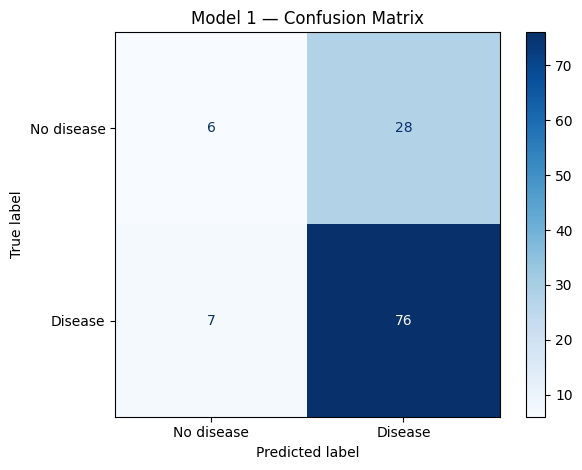

In [22]:
# make the confusion matrix for this best model

# predict the target varaible for the test data using our model
pred = model.predict(X_test)
# make the confusion matrix of the actual and predicted values
cm_m1 = confusion_matrix(y_test, pred)
# make a variable that holds the display of the confusion matrix made above
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['No disease', 'Disease'])
# plot the display of the confusion matrix
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [25]:
print(classification_report(y_test, pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.46      0.18      0.26        34
     Disease       0.73      0.92      0.81        83

    accuracy                           0.70       117
   macro avg       0.60      0.55      0.53       117
weighted avg       0.65      0.70      0.65       117



From looking at the confusion matrix and classification report for the model, we can see that it does pretty well on recall for the positive class (0.92), meaning that it correctly identifies most of the patients with liver disease as having liver disease. This can also be seen in the confusion matrix with how out of the patients that actually had liver disease in the test set, it correctly predicted 78 of them and only had 7 false negatives. The precision on the positive class, or how many of the patients that were predicted to have liver disease actually have it, is also slightly greater than the prevalance (being 0.73), which is also helpful. Where this model is lacking, however, is with both recall and precision on the negative class, but especially with recall. It only predicted that 13 of the 117 patients in the test set didn't have liver disease and was wrong about 7 of them, while also incorrectly classifying 28 patients who didn't have liver disease as having it. This indicates that we could maybe try balancing the class weights, as patients without liver disease made up less than 30% of the training data.

In [ ]:
# make the ROC curve and get the AUC score

# get the probabilities that the model gave each data point in the test set to be in the positive class
y_test_proba = model.predict_proba(X_test)[:,1]
# get the AUC score for the test set
test_auc  = metrics.roc_auc_score(y_test, y_test_proba)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7456



ROC Curve (Test Set):


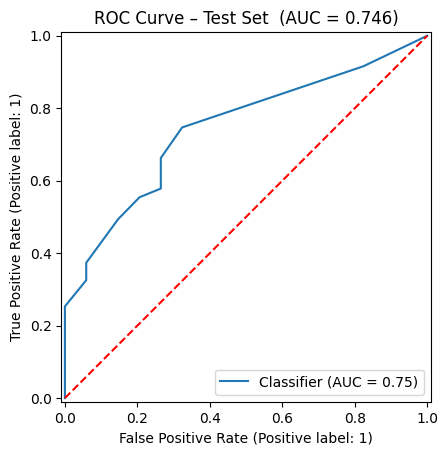

In [ ]:
# plot the ROC curve
print('\nROC Curve (Test Set):')
# make the ROC curve display using the actual values and the probabilities the model assigned each data point to be in each class
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba)
# make the red dotted line that runs from the bottom left to top right corner of the graph, representing random guessing
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

The AUC score is about 0.75, showing that the model is better than random guessing, but is only slightly higher than the prevalance, which is what the accuracy would be if the model guesses everyone to be in the positive class. We can also see that the ROC curve is not in the top left corner of the graph, which is where it would be if the model was more accurate, but it is still above the red line that represents random guessing.

## Make a new model with balanced class weights

In [26]:
# try balancing class weights so that there are less false positives
# make the same pipeline as before, but add class_weight='balanced' in the decision tree
# this will mean that the decision tree weights the classes equally in training, so it will put more stake into the data points in the
# negative class since they were only 30% of the data
model2_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=25, min_samples_split=5, class_weight = 'balanced',
                                          random_state=42))
])
# fit this new pipeline
model2 = model2_pipe.fit(X_train, y_train)

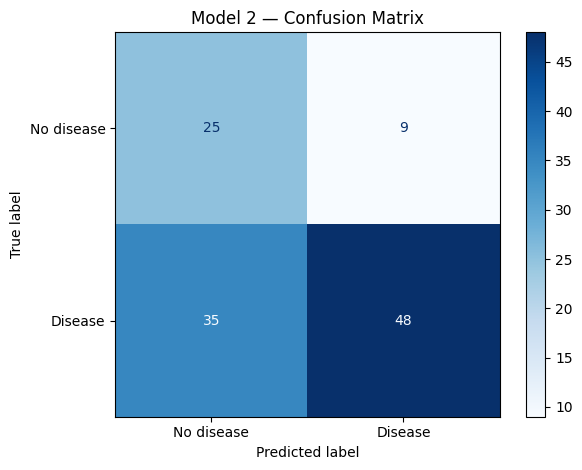

In [27]:
# make the confusion matrix for the balanced class weights

# get the predicted classifications for the test set from the model
pred2 = model2.predict(X_test)
# make the confusion matrix comparing the actual and predicted values
cm_m2 = confusion_matrix(y_test, pred2)
# make a variable that holds the display of the confusion matrix made above
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['No disease', 'Disease'])
# plot the display of the confusion matrix
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [28]:
print(classification_report(y_test, pred2, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.42      0.74      0.53        34
     Disease       0.84      0.58      0.69        83

    accuracy                           0.62       117
   macro avg       0.63      0.66      0.61       117
weighted avg       0.72      0.62      0.64       117



From looking at this confusion matrix and classification report, we can see that the model is predicting much more patients to be in the negative class (not have liver disease), but it's still not very accurate in these predictions. The precision on the positive class and recall on the negative class both increased with balanced class weights, but the recall on the negative class decreased signifigantly, which is problematic. With this model, 35 out of 117 patients are incorrectly classified as not having liver disease when they actually do, which would be detrimental to their care. Thus, although this model is better at correctly predicting patients that don't have liver disease, that isn't worth the increased number of false negatives, which are much worse than false positives. Thus, the first model should be used instead of this one because it had much less false negatives, meaning higher recall on the positive class.

In [ ]:
y_test_proba2 = model2.predict_proba(X_test)[:,1]
test_auc  = metrics.roc_auc_score(y_test, y_test_proba2)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7381



ROC Curve (Test Set):


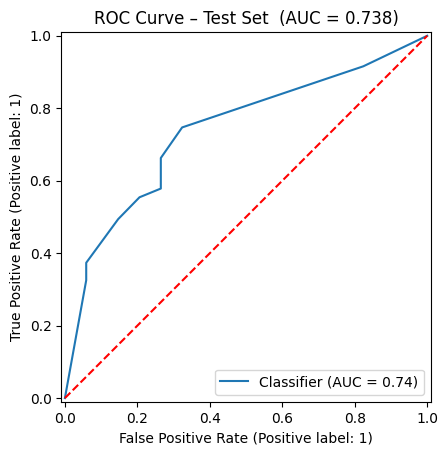

In [ ]:
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba2)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

We can also see that the AUC score went down slightly when the model had banaced class weights, which is another piece of evidence that this model isn't as useful as the first one.

## Try finding the best min impurity decrease to see if that changes the model

In [29]:
# try the grid search with the min impurity decrease
# this is how much a split must improve the purity to be accepted, meaning that a higher one can prevent overfitting
# set the values of min impurity decrease that we want to test
param={"classifier__min_impurity_decrease":[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002]}

In [30]:
# make the pipeline with the parameters from our best model earlier already set
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=25, min_samples_split=5,random_state=42))
])

# do the search on the values of the min impurity decrease with the scoring and cross-validation set above
search = GridSearchCV(pipe, param, scoring=scoring, cv=kf, refit='roc_auc')

# do the search on the training data to get the best value for min imourity decrease
model = search.fit(X_train, y_train)

In [31]:
# make and print the model with the best parameter value
model3 = model.best_estimator_
print(model3)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


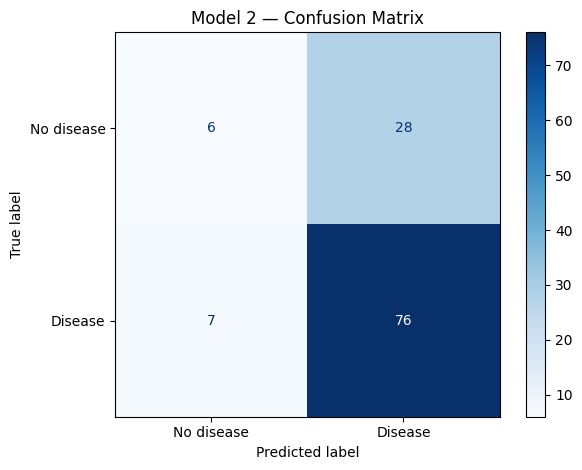

In [32]:
# make the predictions on the test set
pred3 = model3.predict(X_test)
# make the confusion matrix comparing the actual and predicted values
cm_m3 = confusion_matrix(y_test, pred3)
# make a variable that holds the display of the confusion matrix made above
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['No disease', 'Disease'])
# plot the display of the confusion matrix
disp_m3.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [33]:
# print the classification report
print(classification_report(y_test, pred3, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.46      0.18      0.26        34
     Disease       0.73      0.92      0.81        83

    accuracy                           0.70       117
   macro avg       0.60      0.55      0.53       117
weighted avg       0.65      0.70      0.65       117



In [ ]:
# make the ROC curve and get the AUC score
y_test_proba3 = model3.predict_proba(X_test)[:,1]
test_auc  = metrics.roc_auc_score(y_test, y_test_proba3)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7456



ROC Curve (Test Set):


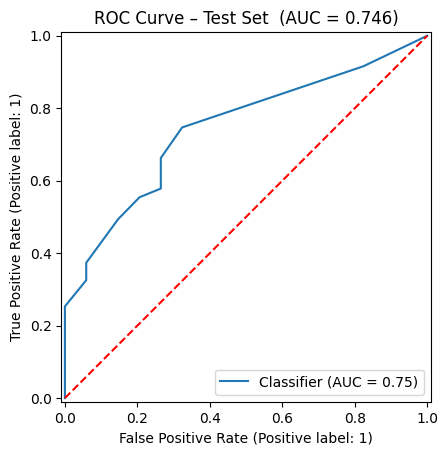

In [ ]:
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba3)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

We can see from the confusion matrix, classification report, ROC curve, and AUC score that changing the min impurity decrease doesn't improve any of the metrics on the test set, however, it also doesn't make any of them worse. Thus, we'll keep this model as it may be better on larger datasets.

## Run Grid Search CV Again, this time on the splitter, max features, and the ccp alpha

In [34]:
# set the parameters that we want to test and the values we want to test
# splitter determines whether the model will look at all possible split points (best) or a random subset of split points (random)
# to determine the best split for each node
# random is faster and can prevent overfitting, but might lead to lower accuracy
param={"classifier__splitter":["best","random"],
       # max features determines the maximum number of features the model can consider when looking for the best split at each node
       "classifier__max_features":["log2","sqrt",None],
       # ccp alpha is the penalty for complexity, meaning that the higher the alpha, the more nodes the tree is likely to remove while pruning
       # after fitting the model
       "classifier__ccp_alpha" :[.001, .01, .1]
       }

In [54]:
# make the pipeline with the best features from earlier specified in the decision tree
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_impurity_decrease=0.0005,
                                          min_samples_leaf=25, min_samples_split=5, random_state=42))
])

# do grid search cv on the pipeline looking through the 3 parameters shown above
search = GridSearchCV(pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')

# fit the search on the training data
model = search.fit(X_train, y_train)

In [55]:
# retrieve and print the model with the best parameters according to the search above
model4 = model.best_estimator_
print(model4)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(ccp_alpha=0.01, max_depth=4,
                                        max_features='log2', max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


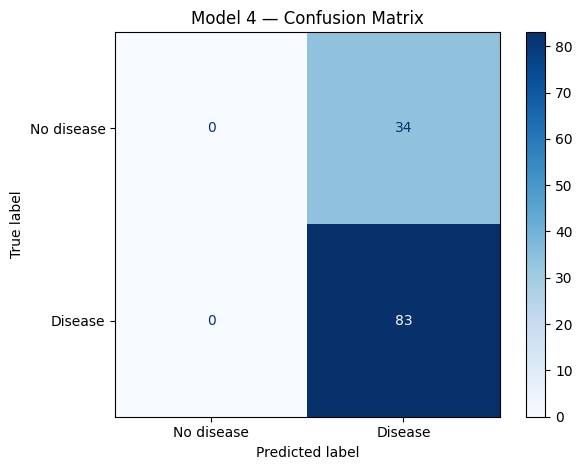

In [56]:
# make the confusion matrix for this best model

# get the predicions for the test set with model4
pred4 = model4.predict(X_test)
# make a confusion matrix of the predicted and actual values
cm_m4 = confusion_matrix(y_test, pred4)
# make a variable that holds the display of the confusion matrix made above
disp_m4 = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['No disease', 'Disease'])
# plot the display of the confusion matrix
disp_m4.plot(cmap='Blues')
plt.title('Model 4 — Confusion Matrix')
plt.tight_layout()
plt.show()

We can see from this confusion matrix that the new model is just predicting every patient to have liver disease. This maximizes recall, however, it means that the model isn't useful at all, so we won't use this one. We can try balancing class weights while running the grid search to see if that improves the model since it should stop it from predicting every patient to have liver disease

In [57]:
# make the pipeline with the best features from earlier specified in the decision tree
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_impurity_decrease=0.0005,
                                          min_samples_leaf=25, min_samples_split=5, class_weight='balanced',random_state=42))
])

# do grid search cv on the pipeline looking through the 3 parameters shown above
search = GridSearchCV(pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')

# fit the search on the training data
model = search.fit(X_train, y_train)

In [58]:
# retrieve and print the model with the best parameters according to the search above
model5 = model.best_estimator_
print(model5)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_encoder',
                                                  OneHotEncoder(),
                                                  ['Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                                        max_depth=4, max_features='log2',
                                        max_leaf_nodes=10,
                                        min_impurity_decrease=0.0005,
                                        min_samples_leaf=25,
                                        min_samples_split=5,
                                        random_state=42))])


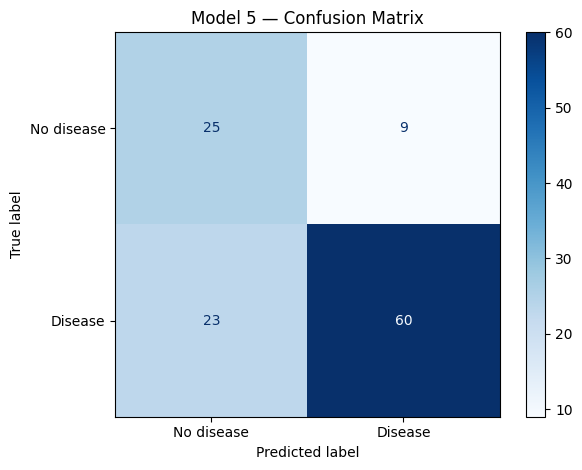

In [60]:
# make the confusion matrix for this best model

# get the predicions for the test set with model4
pred5 = model5.predict(X_test)
# make a confusion matrix of the predicted and actual values
cm_m5 = confusion_matrix(y_test, pred5)
# make a variable that holds the display of the confusion matrix made above
disp_m5 = ConfusionMatrixDisplay(confusion_matrix=cm_m5, display_labels=['No disease', 'Disease'])
# plot the display of the confusion matrix
disp_m5.plot(cmap='Blues')
plt.title('Model 5 — Confusion Matrix')
plt.tight_layout()
plt.show()

In [61]:
print(classification_report(y_test, pred5, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.52      0.74      0.61        34
     Disease       0.87      0.72      0.79        83

    accuracy                           0.73       117
   macro avg       0.70      0.73      0.70       117
weighted avg       0.77      0.73      0.74       117



In [62]:
# make the ROC curve and get the AUC score
y_test_proba5 = model5.predict_proba(X_test)[:,1]
test_auc  = metrics.roc_auc_score(y_test, y_test_proba4)
print(f'AUC score: {test_auc:.4f}')

AUC score: 0.7642



ROC Curve (Test Set):


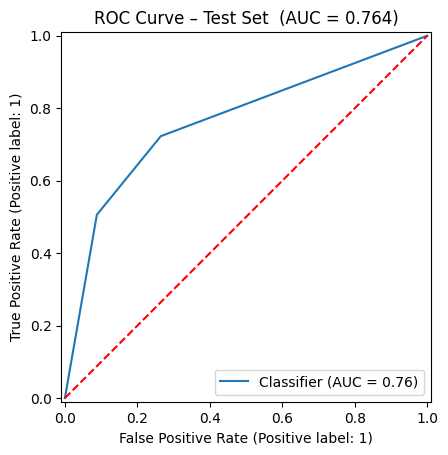

In [63]:
print('\nROC Curve (Test Set):')
metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba5)
plt.plot([0, 1], [0, 1], 'r--')
plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
plt.show()

This new model has a higher AUC score and both higher precision on the positive class and higher recall on the negative class, however, it still predicts more false negatives than our best model from earlier (model 3). It has less overall incorrect predictions, but since there are more false negatives, it's not the ideal model for our purposes. This is an example of how sometimes there's a tradeoff between overall accuracy and another metric so that overall accuracy isn't always the best indicator of the best model.

## Get the most important features in the decision tree

In [65]:
# get the feature importances for the classifier of our best model (model 3)
importances = model3.named_steps['classifier'].feature_importances_
print(importances)

[0.         0.         0.11088828 0.45788417 0.06529401 0.27738866
 0.08854489 0.         0.         0.         0.        ]


In [66]:
# print the order of the columns in X, but know that the one hot encoding will make the first two columns gender_male and gender_female in the
# decision tree, meaning that age is now the third column when shown in feature importances and every other column is one after the index shown
# here
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
dtypes: float64(5), int64(4), object(1)
memory usage: 45.7+ KB


From comparing the feature importances to the columns, we can see that TB is the most important feature in depending if a patient has liver disease. Alkphos is the next most important feature, and then age. We can see that gender, Sgot, TP, ALB, and A/G Ratio have no impact on the model and the rest of the feaures only have a small impact on it. TB stands for Total Bilirubin level, and bilirubin is a waste product that's processed in the liver from the natural breakdown of red blood cells. High levels of it are known to indicate liver disease. The average level in healthy adults is 0.1 to 1.2 mg/dL, and this dataset had a mean level of about 3.3, so it makes sense that this would be a strong indicator of liver disease. Alkphos is an enzyme that's found in the body, but especially the liver, that breaks down protiens and aids in metabolic processes. It's also used frequently to detect liver disease, with average healthy levels being between 44 to 147 IU/L. For our dataset, the mean was 290.58, which, again is out of healthy levels. As you get older, your liver shrinks, reduces bloodflow, and regenerates less, so it makes sense that age also contributed to the prediction from the model.


## Overall Takeaways from Decision Tree Model

This model can serve as a good starting point for doctors trying to diagnose liver disease, but it shouldn't lead to a definitive diagnosis. On our test data it works well enough to give a baseline idea of if a patient might have liver disease, however it has some issues so it should only be used to identify if a patient should be sent to extra testing. Since the dataset is small and only contains informations from patients in the North-East region of Andhra Pradesh, India, we can't say for sure that it will be accurate for people from other regions of the world, as there might be regional differences in some of these levels that would lead to more incorrect classifications. Due to the dataset being small, we also don't know how well this captures overall trends, so additional testing on other datasets with the same features would be helpful. The model could also be retrained on a larger dataset, which would likely increase accuracy. The new data should also have a more balanced amount of patients who do and do not have liver disease, as the high prevalance in this dataset led to the model predicting very few people to not have liver disease. The feature importances can give some useful information to doctors, as it shows what tests to prioritize when trying to diagose a patient.